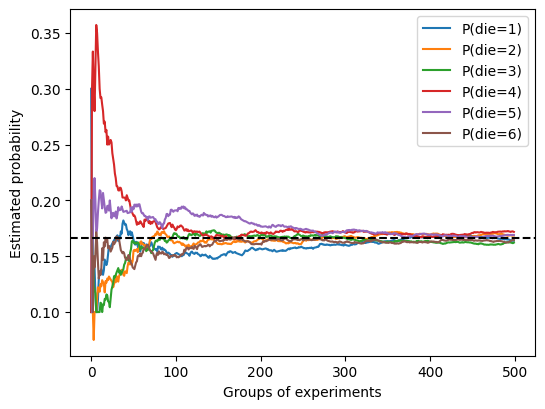

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.16MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 138kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.48MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


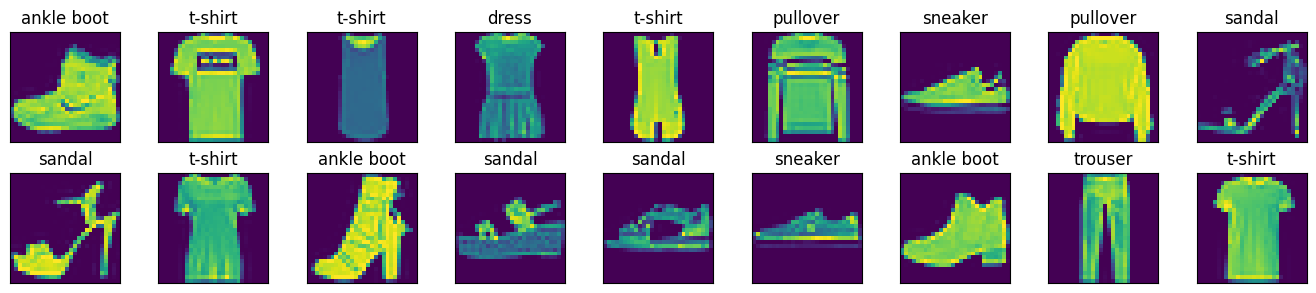

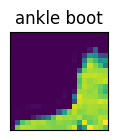

In [1]:

import cv2
import random
import matplotlib.pyplot as plt
import torch
from torch.distributions import multinomial
from torch.utils import data
import torchvision
from torchvision import datasets
from torchvision import transforms

def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plota uma lista de imagens."""
    figsize = (num_cols * scale, num_rows * scale)
    #_, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Imagem em tensor
            ax.imshow(img.numpy())
        else:
            # Imagem PIL
            ax.imshow(img)

        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)

        if titles:
            ax.set_title(titles[i])

    plt.tight_layout()
    return axes


def main():
    # print("Opa, tudo certo! Vamos começar a usar o PyTorch e o OpenCV.")
    # x = torch.arange(12)
    # print(x)
    # print(x.shape)

    # X = x.reshape(3, 4)
    # print(X)

    # x = torch.zeros(12, 3)
    # print(x)
    # Probabilidades de um dado honesto
    fair_probs = torch.ones(6) / 6

    # Simula 500 grupos de 10 lançamentos
    counts = multinomial.Multinomial(10, fair_probs).sample((500,))
    cum_counts = counts.cumsum(dim=0)
    estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

    # Define o tamanho da figura
    plt.figure(figsize=(6, 4.5))

    # Plota a probabilidade estimada para cada face
    for i in range(6):
        plt.plot(estimates[:, i].numpy(),
                label=f'P(die={i+1})')

    # Linha horizontal indicando a probabilidade teórica (1/6)
    plt.axhline(y=1/6, color='black', linestyle='dashed')

    # Rótulos dos eixos
    plt.xlabel('Groups of experiments')
    plt.ylabel('Estimated probability')

    # Legenda
    plt.legend()

    # Exibe o gráfico
    plt.show()

    #slide 51
    trans = transforms.ToTensor()
    mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

    #slide 56
    X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
    show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y));

    #slide 57
    X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))

    # Primeira imagem, metade superior esquerda
    img_parcial = X[0, 0, :19, :19]

    show_images(img_parcial.reshape(1, 19, 19), 1, 1, titles=[get_fashion_mnist_labels(y)[0]]);



if __name__ == "__main__":
    main()

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.26MB/s]


Quantidade de imagens no treino: 60000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


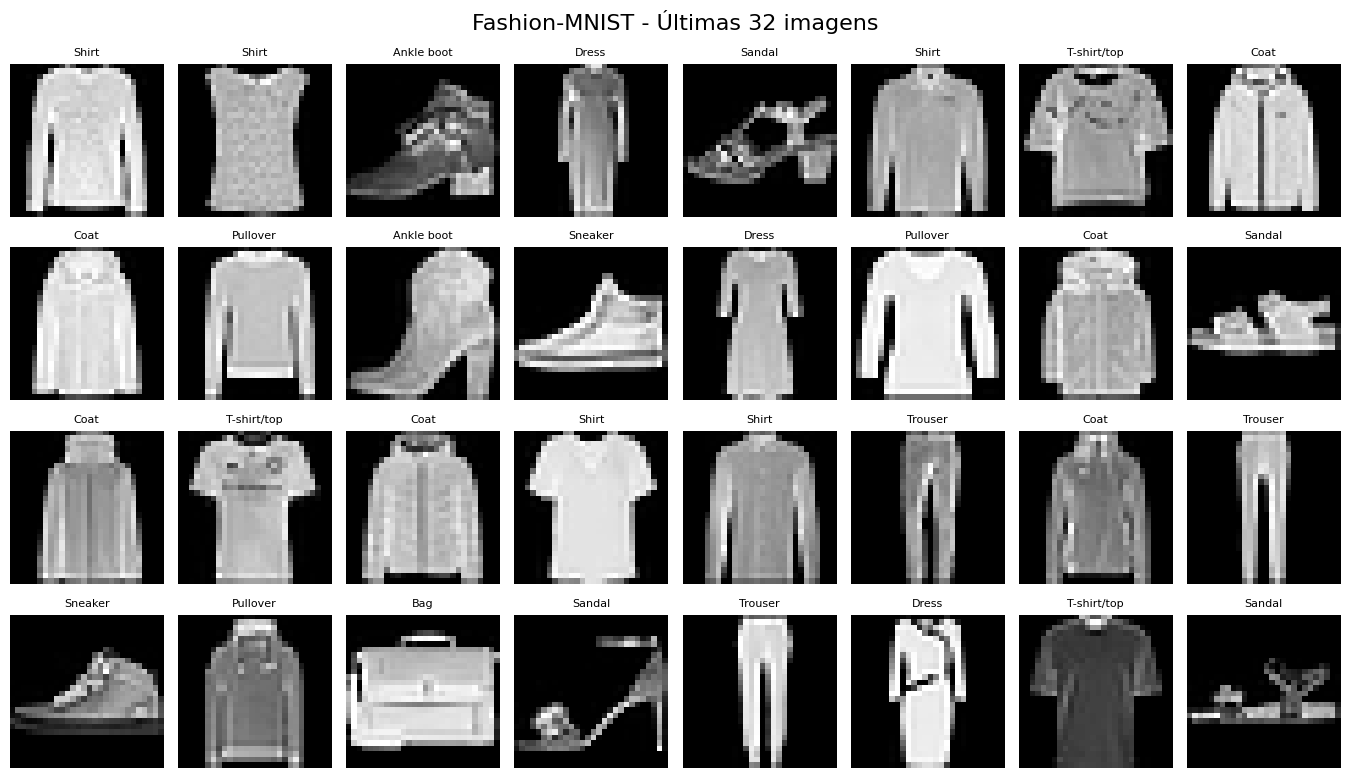

In [2]:
import random
import matplotlib.pyplot as plt
from torchvision import datasets

fashion_train = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True
)

def exibir_imagens(dataset, indices, titulo, ncols=8):
    n = len(indices)
    nrows = (n + ncols - 1) // ncols

    plt.figure(figsize=(ncols * 1.7, nrows * 2))
    plt.suptitle(titulo, fontsize=16)

    classes = getattr(dataset, "classes", None)

    for i, idx in enumerate(indices):
        imagem, rotulo = dataset[idx]

        plt.subplot(nrows, ncols, i + 1)

        if imagem.mode == "L":
            plt.imshow(imagem, cmap="gray")
        else:
            plt.imshow(imagem)

        if classes is not None and rotulo < len(classes):
            plt.title(classes[rotulo], fontsize=8)
        else:
            plt.title(str(rotulo), fontsize=8)

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    fashion_train = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True
)

print("Quantidade de imagens no treino:", len(fashion_train))
print("Classes:", fashion_train.classes)


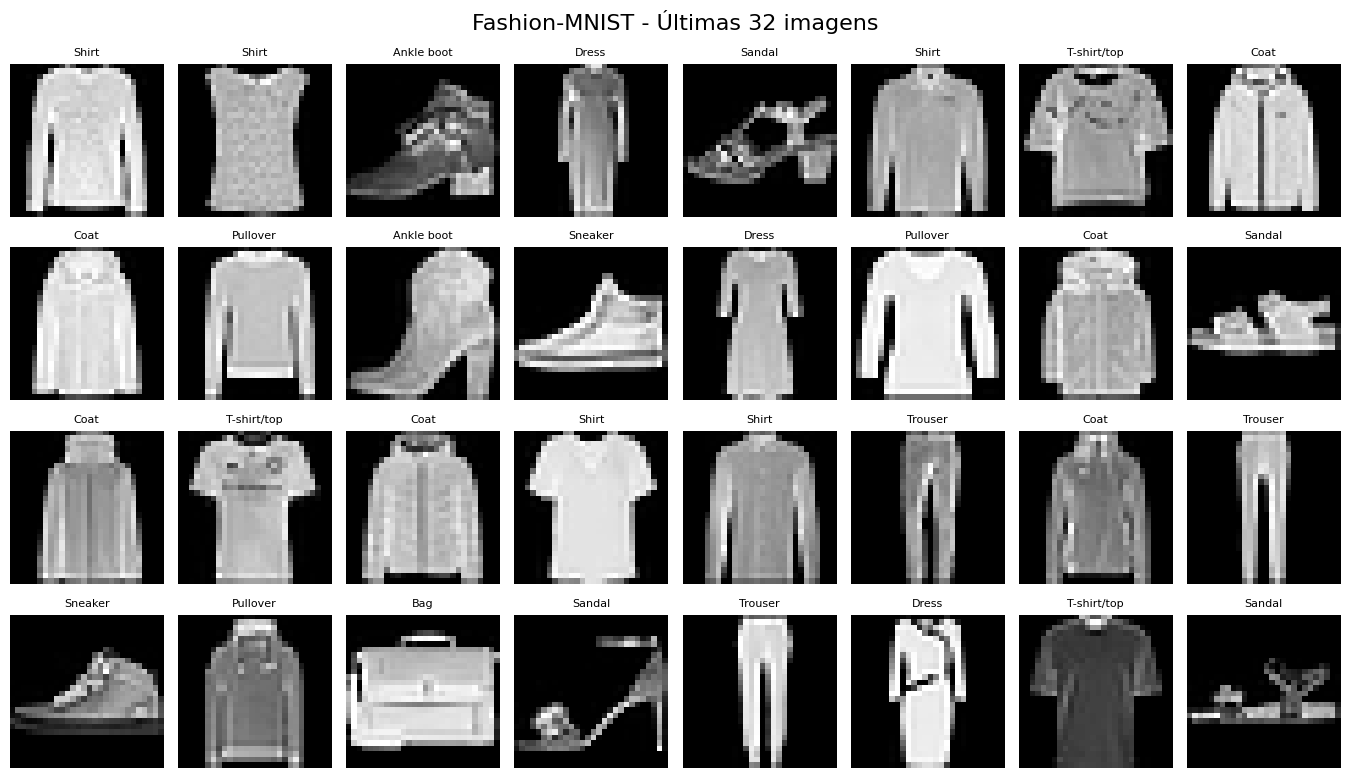

In [3]:
ultimas_imagens = list(range(len(fashion_train) - 32, len(fashion_train)))

exibir_imagens(
    fashion_train,
    ultimas_imagens,
    "Fashion-MNIST - Últimas 32 imagens"
)

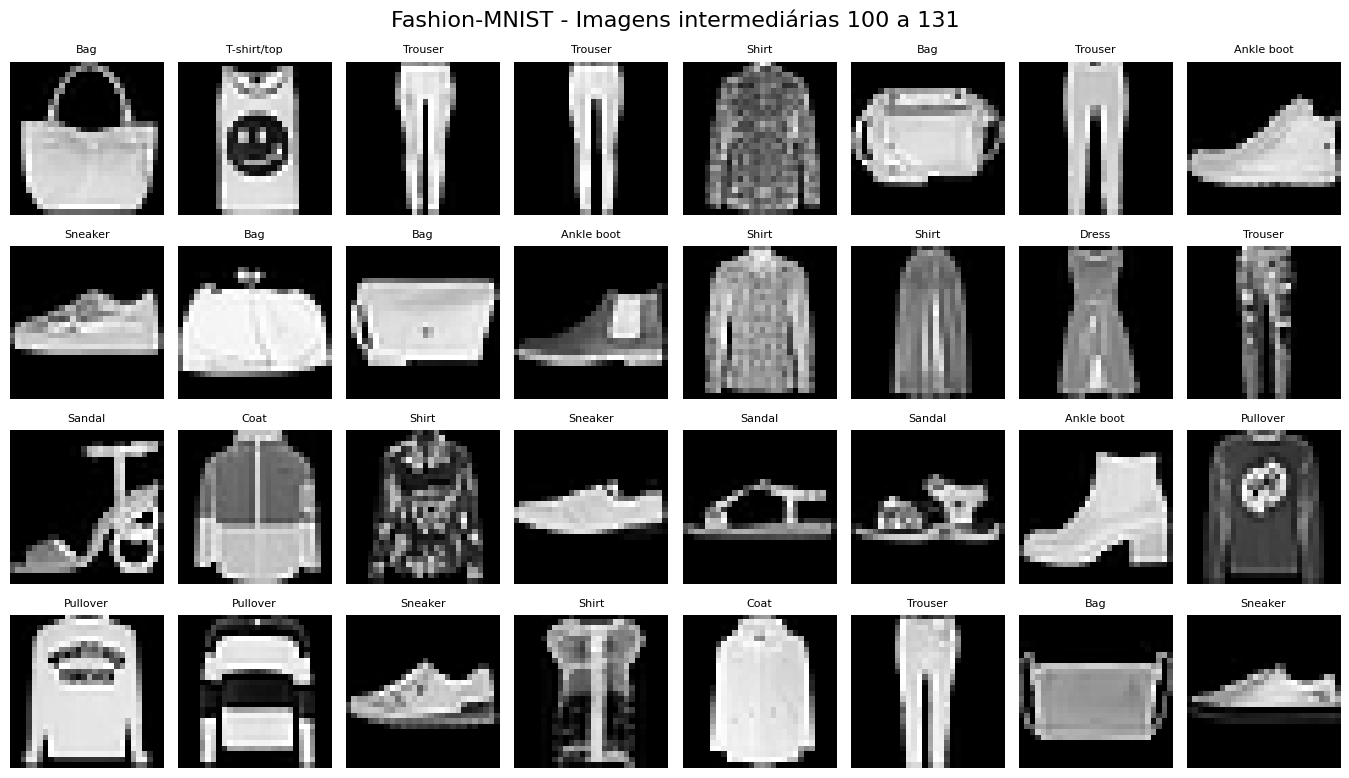

In [4]:
intermediarias_1 = list(range(100, 132))

exibir_imagens(
    fashion_train,
    intermediarias_1,
    "Fashion-MNIST - Imagens intermediárias 100 a 131"
)

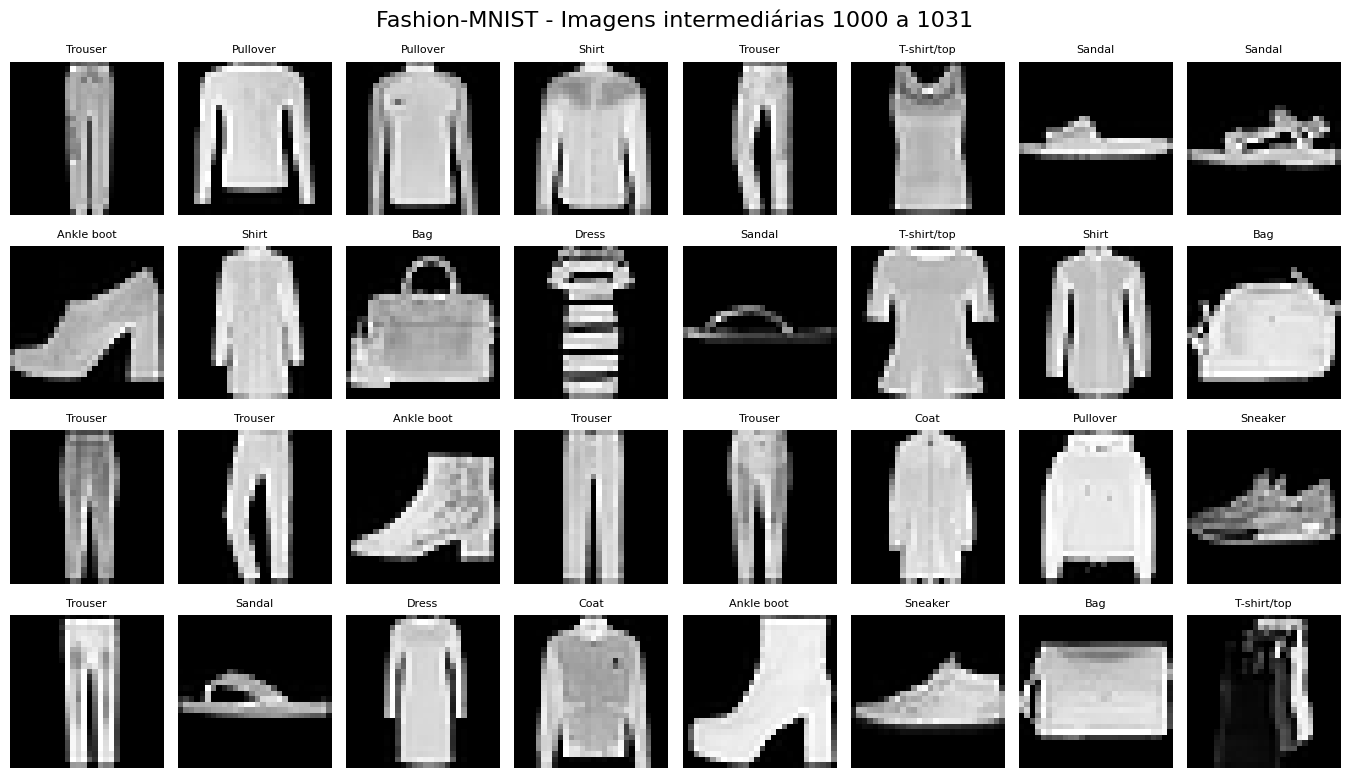

In [5]:
intermediarias_2 = list(range(1000, 1032))

exibir_imagens(
    fashion_train,
    intermediarias_2,
    "Fashion-MNIST - Imagens intermediárias 1000 a 1031"
)

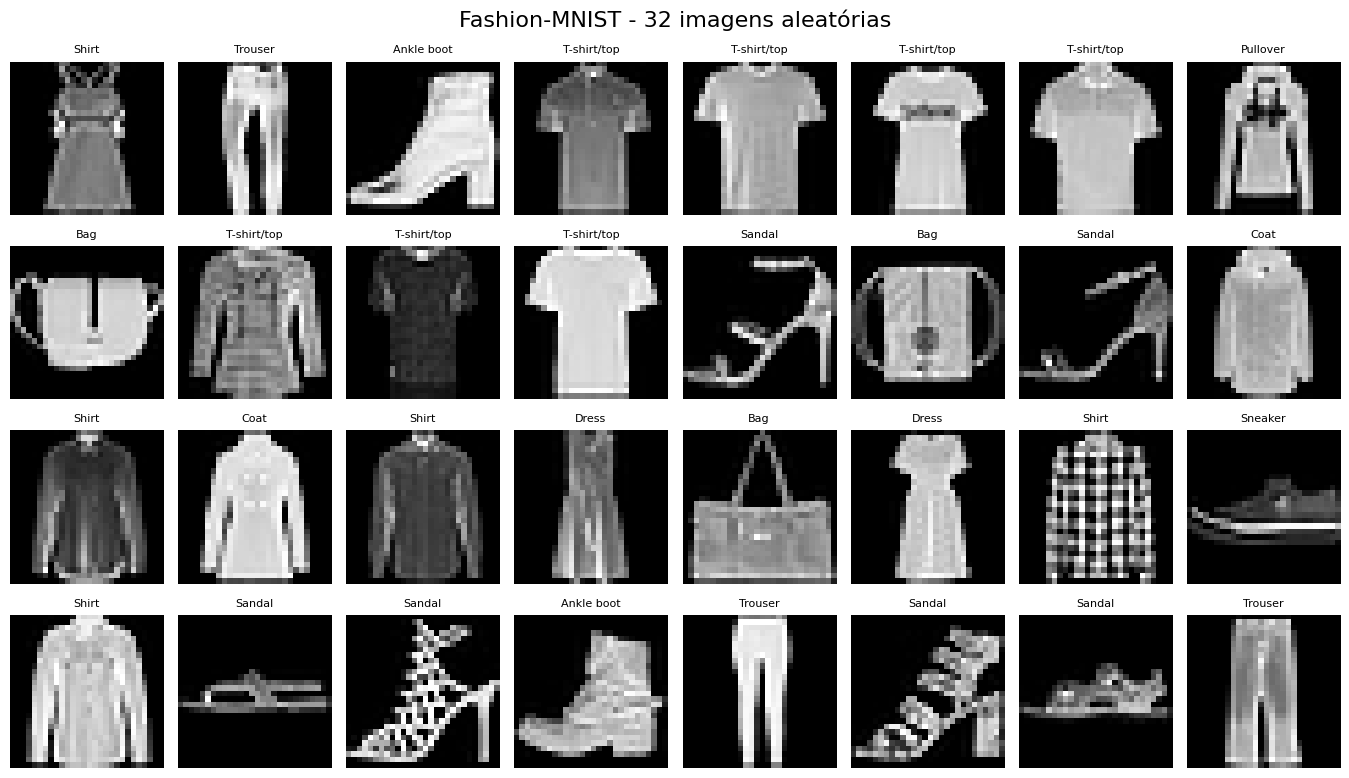

In [6]:
random.seed(42)

indices_aleatorios = random.sample(
    range(len(fashion_train)),
    32
)

exibir_imagens(
    fashion_train,
    indices_aleatorios,
    "Fashion-MNIST - 32 imagens aleatórias"
)

100%|██████████| 170M/170M [00:02<00:00, 73.6MB/s]


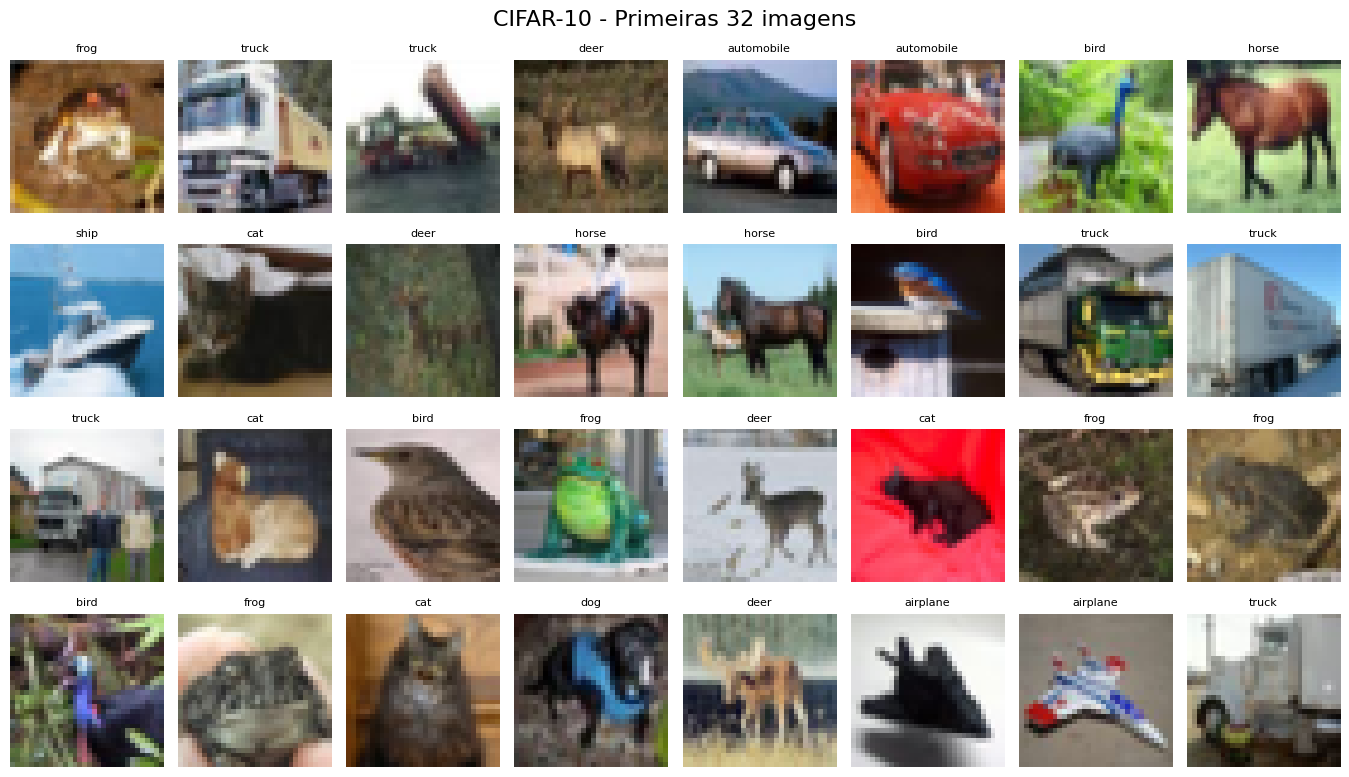

In [7]:
cifar10 = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

exibir_imagens(
    cifar10,
    list(range(32)),
    "CIFAR-10 - Primeiras 32 imagens"
)

100%|██████████| 18.2M/18.2M [00:14<00:00, 1.27MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 3.04M/3.04M [00:03<00:00, 940kB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 14.7MB/s]


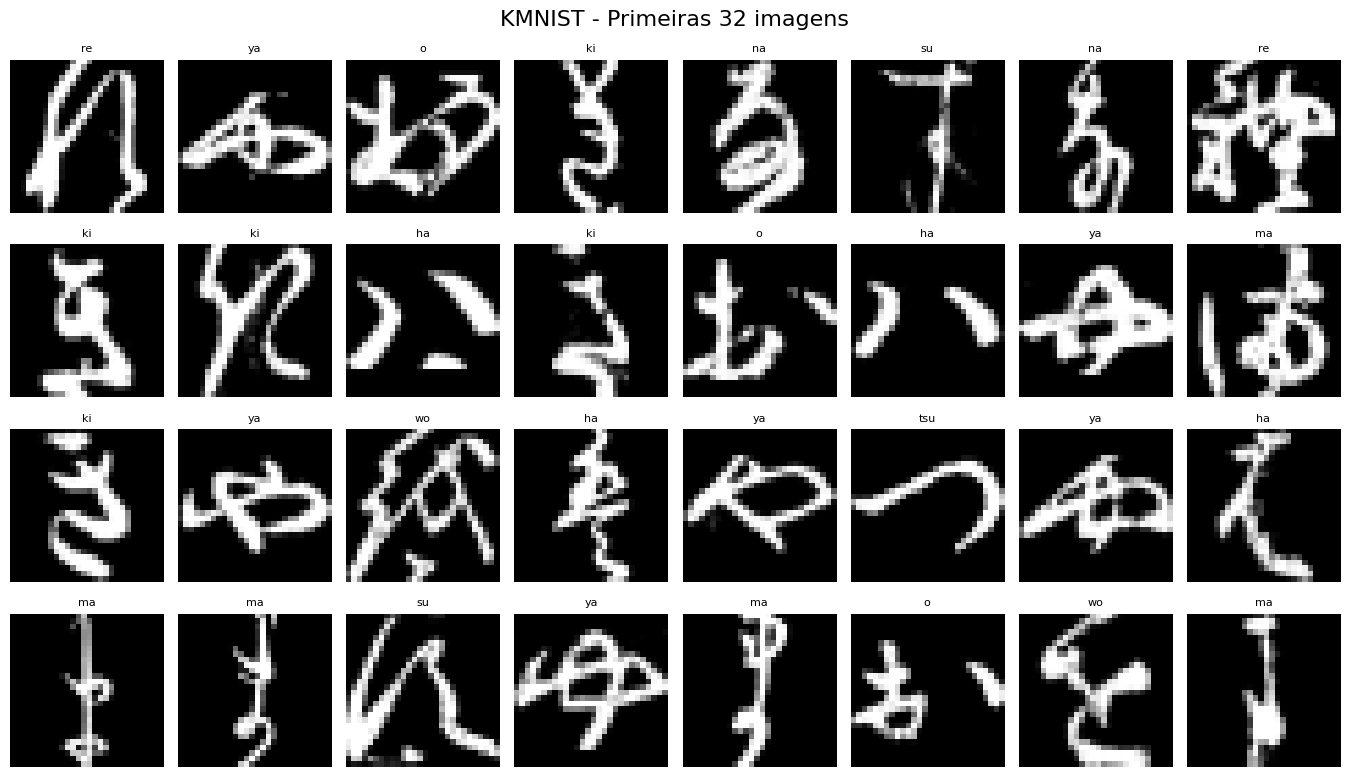

In [8]:
kmnist = datasets.KMNIST(
    root="./data",
    train=True,
    download=True
)

exibir_imagens(
    kmnist,
    list(range(32)),
    "KMNIST - Primeiras 32 imagens"
)

100%|██████████| 562M/562M [00:07<00:00, 72.8MB/s]


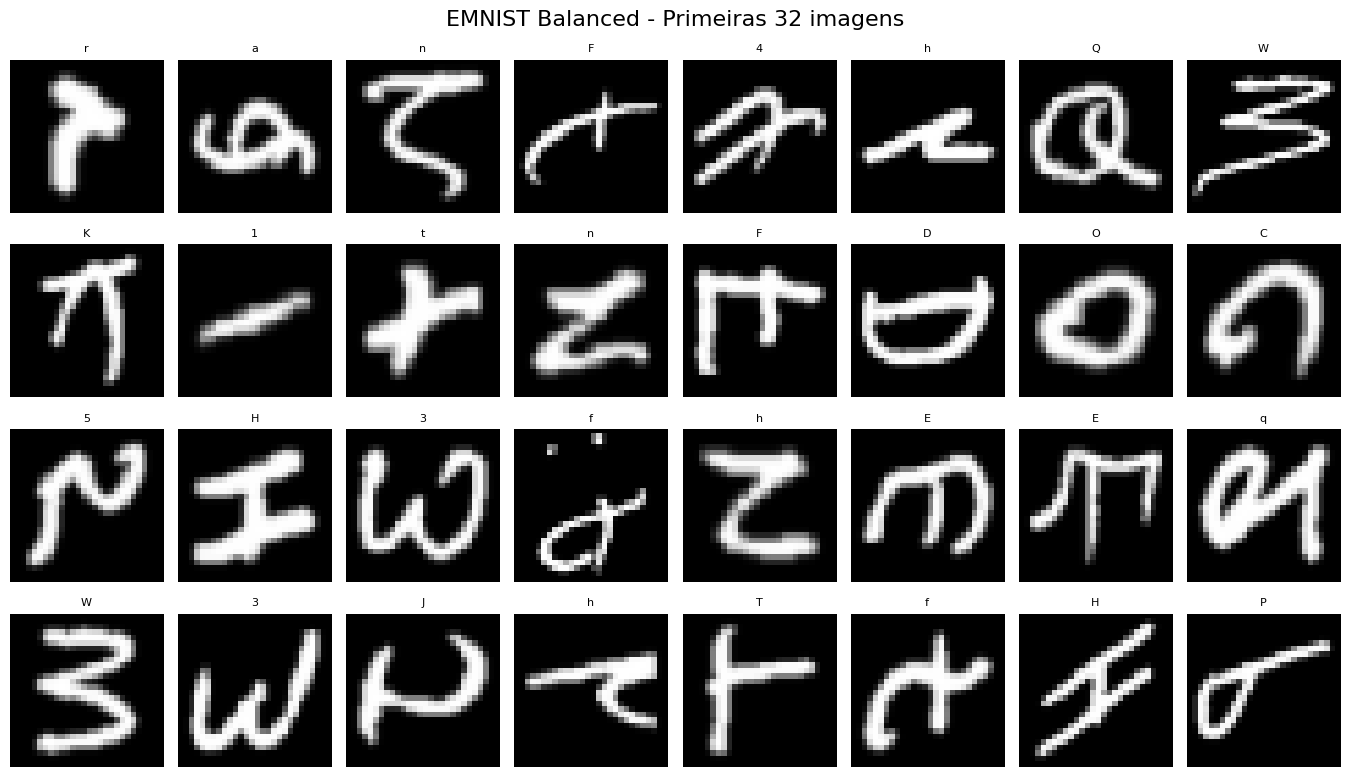

In [9]:
emnist = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True
)

exibir_imagens(
    emnist,
    list(range(32)),
    "EMNIST Balanced - Primeiras 32 imagens"
)

## Conclusão

Nesta atividade, foram aplicados conceitos de manipulação, indexação e fatiamento de datasets de imagens. Inicialmente, foi utilizado o Fashion-MNIST, dataset apresentado no contexto da aula, para exibir as últimas imagens, dois conjuntos intermediários e imagens aleatórias. Em seguida, foram carregados e visualizados três outros datasets: CIFAR-10, KMNIST e EMNIST.

A atividade permitiu observar como diferentes conjuntos de imagens podem ser acessados por meio de índices, como os dados podem ser fatiados em intervalos específicos e como bibliotecas como PyTorch/Torchvision auxiliam na aquisição, organização e visualização de datasets para aplicações em visão computacional.